In [1]:
import gymnasium
from gymnasium import logger as gymlogger
from gymnasium.wrappers import RecordVideo
import tensorflow as tf
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
import math
import copy
import glob
import io
import base64
from IPython.display import HTML

from IPython import display as ipythondisplay

In [2]:
"""
Utility functions to enable video recording of gym environment and displaying it
To enable video, just do "env = wrap_env(env)""
"""

def show_video():
  mp4list = glob.glob('./CartPole_videos/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay 
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else: 
    print("Could not find video")
    

def wrap_env(env):
  env = RecordVideo(env, video_folder="./CartPole_videos")
  return env

In [3]:
class NeuralNetwork:

  def __init__(self, env):
      self.env = env
      self.weightsIn = np.array([np.random.uniform(-1, 1, 2), np.random.uniform(-1, 1, 2), np.random.uniform(-1, 1, 2), np.random.uniform(-1, 1, 2)]) 
      self.score = 0


  def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

  def feed_forward(self, obs):
      self.output = self.sigmoid(np.dot(obs, self.weightsIn))
      action = np.argmax(self.output)
      return action

  def run3(self, truth):
      tempscore = 0
      self.run(truth)
      tempscore += self.score
      self.run(truth)
      tempscore += self.score
      self.run(truth)
      tempscore += self.score
      self.score = tempscore/3

  def run(self, truth):
        self.score = 0
        holder = self.env.reset()
        action = self.feed_forward(holder[0])
        new_obs, reward, is_done, truncation, _ = self.env.step(action)
        while not is_done and not truncation:
            self.score += reward
            if truth is True:
              self.env.render()
            action = self.feed_forward(np.array(new_obs))
            new_obs, reward, is_done, truncation, _ = self.env.step(action)
            #plt.imshow(env.render('rgb_array'))
            

  def fitness(self):
      return self.score

  def weights(self):
      return self.weightsIn #, self.weightsHid

  def setWeights(self, weightsIn): #, weightsHid):
      self.weightsIn = weightsIn
      #self.weightsHid = weightsHid

In [5]:
#Test one NN
env = gymnasium.make("CartPole-v1", render_mode="rgb_array")
env = wrap_env(env)
NN = NeuralNetwork(env)
NN.run3(True)

env.close()
show_video()

In [6]:
def generate_population (n):
  parents = []
  env = gymnasium.make("CartPole-v1", render_mode="rgb_array")
  for t in range (n):
    generated = NeuralNetwork(env)
    parents.append(generated)
  return parents

#parents = generate_population(64)

In [7]:
def fit_func(generated):
  generated.run(False)
  return generated.fitness()

In [8]:
env = gymnasium.make("CartPole-v1", render_mode="rgb_array")
generated = NeuralNetwork(env)
fit_func(generated)

8.0

In [9]:
n = 3
top = n/3
newpop = 2

In [10]:
#for now just selecting top half
#will have to implement tournament style later
def select_top_parents (target, parents):
  fit = []
  found = False
  for i in range(len(parents)):
    fit.append (fit_func(parents[i]))

  top_idx = np.argsort(fit)[-int(top):]
  top_values = [fit[i] for i in top_idx]

  #target should be 200
  if max(top_values) >= target:
    found = True
  
  best = parents[top_idx[-1]]

  selected = []
  for i in range(len(parents)):
    if i in top_idx:
      selected.append(parents[i])
  
  return selected, found, best


In [11]:
#changes the weights randomly slightly
#can def be streamlined with better numpy code
def mutation(NN, mutation_threshold):
  #mutation_threshold should be less than 1, but >= 0, ideally less than 0.1

  env = gymnasium.make("CartPole-v1", render_mode="rgb_array")
  generated = NeuralNetwork(env)

  generated.weightsIn = np.copy(NN.weightsIn)
  
  # x_indices = np.arange(len(generated.weightsIn))
  # y_indices = np.arange(len(generated.weightsIn[0]))

  # random_x = random.choice(x_indices)
  # random_y = random.choice(y_indices)

#   print("Before:", generated.weightsIn)

  # change = random.uniform(mutation_threshold*-1, mutation_threshold)
  # while generated.weightsIn[random_x][random_y] + change >= 1 and generated.weightsIn[random_x][random_y] + change <= -1:
  #      change = random.uniform(mutation_threshold*-1, mutation_threshold)
  # generated.weightsIn[random_x][random_y] += change

#   print("After:", generated.weightsIn)

  #copied these loops from https://numpy.org/doc/stable/reference/arrays.nditer.html
  with np.nditer(generated.weightsIn, op_flags=['readwrite']) as it:
   for x in it:
     change = random.uniform(mutation_threshold*-1, mutation_threshold)
     while x + change >= 1 and x + change <= -1:
       change = random.uniform(mutation_threshold*-1, mutation_threshold)
     x[...] = x + change

  # generated.weightsHid = np.copy(NN.weightsHid)
  # with np.nditer(generated.weightsHid, op_flags=['readwrite']) as it:
  #  for x in it:
  #    change = random.uniform(mutation_threshold*-1, mutation_threshold)
  #    while x + change >= 1 or x + change <= -1:
  #      change = random.uniform(mutation_threshold*-1, mutation_threshold)
  #    x[...] = x + change

  return generated

In [12]:
def GA(selection, mt, mp):
  target = 499 #The target value that the neural network should reach for
  print ("target: ", target)   #target should be 499

  parents = generate_population(n) #generate the parents

  found = False 
  iteration_num = 0

  fitness_values = []
  best_score = 0

  current_scores = []
  avg_scores = []

  best_Val = 0
  while True: #The while loop ends when there has been 4000 iterations
    iteration_num +=1
    print("Iteration #: ", iteration_num)
    selected, found, best = select_top_parents (target, parents)
    fitness_values.append(best.score)
    current_scores.append(best.score)
    print("Score: ", best.score)
    # if len(current_scores) == 10:
    #   avg = np.average(current_scores)
    #   if avg >= 400:
    #     break
    #   else:
    #     current_scores.pop(0)

    sums = 0
    for i in range(10):
      sums+=fit_func(best)
    avg_scores.append(sums/10)
    if sums/10 >= 400:
      break

    mutated = []
    mutation_threshold = mt
    #for NN in selected:
    while(len(mutated) < newpop):
      chosen = random.choice(selected)
      if random.random()<=mp:
        mutated.append(mutation(chosen, mutation_threshold))
      else:
        #append a copy
        mutated.append(copy.copy(chosen))
    
    parents = selected+mutated
    print("Length of Population:", len(parents))
    print()

  print("Final Generation: ", iteration_num)
  return fitness_values, best, avg_scores

In [13]:
def GABrandon(selection, mt, mp):
  target = 499 #The target value that the neural network should reach for
  print ("target: ", target)   #target should be 499

  parents = generate_population(n) #generate the parents

  found = False 
  iteration_num = 0

  fitness_values = []
  best_score = 0

  current_scores = []
  avg_scores = []

  best_Val = 0
  while True: #The while loop ends when there has been 4000 iterations
    iteration_num +=1
    print("Iteration #: ", iteration_num)
    selected, found, best = select_top_parents (target, parents)
    fitness_values.append(best.score)
    current_scores.append(best.score)
    print("Score: ", best.score)
    # if len(current_scores) == 10:
    #   avg = np.average(current_scores)
    #   if avg >= 400:
    #     break
    #   else:
    #     current_scores.pop(0)

    sums = 0
    for i in range(10):
      sums+=fit_func(best)
    avg_scores.append(sums/10)
    if len(fitness_values) > 10 and sum(fitness_values[-10:])/10 >= 400:
      break

    mutated = []
    mutation_threshold = mt
    #for NN in selected:
    while(len(mutated) < newpop):
      chosen = random.choice(selected)
      if random.random()<=mp:
        mutated.append(mutation(chosen, mutation_threshold))
      else:
        #append a copy
        mutated.append(copy.copy(chosen))
    
    parents = selected+mutated
    print("Length of Population:", len(parents))
    print()

  print("Final Generation: ", iteration_num)
  return fitness_values, best, avg_scores

In [14]:
def visualize(best):
  env = gymnasium.make('CartPole-v1', render_mode="rgb_array")
  env = wrap_env(env)

  FinalNN = NeuralNetwork(env)
  W = best.weights()
  FinalNN.setWeights(W)

  FinalNN.run3(True)
  print(FinalNN.fitness())

  env.close()
  show_video()

target:  499
Iteration #:  1
Score:  9.0
Length of Population: 3

Iteration #:  2
Score:  8.0
Length of Population: 3

Iteration #:  3
Score:  8.0
Length of Population: 3

Iteration #:  4
Score:  9.0
Length of Population: 3

Iteration #:  5
Score:  9.0
Length of Population: 3

Iteration #:  6
Score:  9.0
Length of Population: 3

Iteration #:  7
Score:  9.0
Length of Population: 3

Iteration #:  8
Score:  8.0
Length of Population: 3

Iteration #:  9
Score:  9.0
Length of Population: 3

Iteration #:  10
Score:  8.0
Length of Population: 3

Iteration #:  11
Score:  9.0
Length of Population: 3

Iteration #:  12
Score:  8.0
Length of Population: 3

Iteration #:  13
Score:  9.0
Length of Population: 3

Iteration #:  14
Score:  8.0
Length of Population: 3

Iteration #:  15
Score:  8.0
Length of Population: 3

Iteration #:  16
Score:  8.0
Length of Population: 3

Iteration #:  17
Score:  8.0
Length of Population: 3

Iteration #:  18
Score:  9.0
Length of Population: 3

Iteration #:  19
Score: 

C:\Users\foggb\AppData\Local\Programs\Python\Python310\lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at C:\Users\foggb\Desktop\RPI\Quantum\Project\CartPole_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


336.0


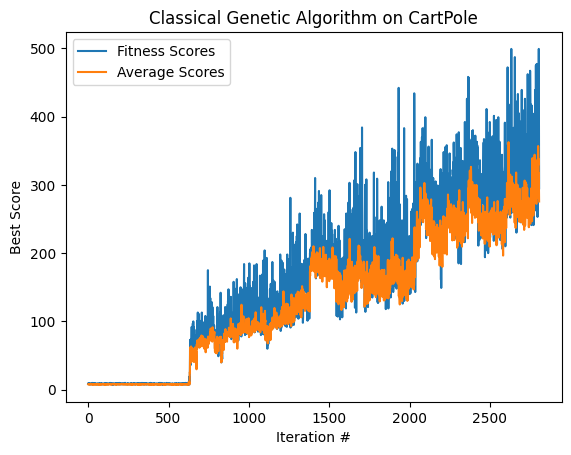

In [15]:
#first parameter determines selection method, second determines how much a 
#weight can be nudged by, and third is what percent do not get mutated
#Select top half best perforers

# Test 1: 3*4*2 = 24
n = 3
top = n/3
newpop = 2

fitness1, best1, average1 = GABrandon(select_top_parents, 0.05, 0.1)
print(best1.weights())
print(fitness1)
visualize(best1)

plt.xlabel("Iteration #")
plt.ylabel("Best Score")
plt.title("Classical Genetic Algorithm on CartPole")
plt.plot(fitness1)
plt.plot(average1)
plt.legend(["Fitness Scores", "Average Scores"])


# fitness4, best = GA(select_top_parents, 0.01, 0.2)#much more wild mutation
# visualize(best)

target:  499
Iteration #:  1
Score:  115.0
Length of Population: 4

Iteration #:  2
Score:  93.0
Length of Population: 4

Iteration #:  3
Score:  121.0
Length of Population: 4

Iteration #:  4
Score:  109.0
Length of Population: 4

Iteration #:  5
Score:  173.0
Length of Population: 4

Iteration #:  6
Score:  161.0
Length of Population: 4

Iteration #:  7
Score:  162.0
Length of Population: 4

Iteration #:  8
Score:  127.0
Length of Population: 4

Iteration #:  9
Score:  215.0
Length of Population: 4

Iteration #:  10
Score:  236.0
Length of Population: 4

Iteration #:  11
Score:  126.0
Length of Population: 4

Iteration #:  12
Score:  142.0
Length of Population: 4

Iteration #:  13
Score:  152.0
Length of Population: 4

Iteration #:  14
Score:  160.0
Length of Population: 4

Iteration #:  15
Score:  146.0
Length of Population: 4

Iteration #:  16
Score:  288.0
Length of Population: 4

Iteration #:  17
Score:  168.0
Length of Population: 4

Iteration #:  18
Score:  200.0
Length of Popu

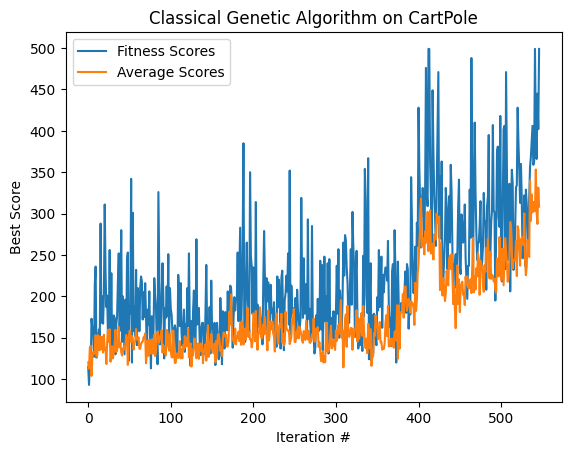

In [16]:
# Test 2: 4*4*2 = 32
n = 4
top = n/2
newpop = 2

fitness2, best2, average2 = GABrandon(select_top_parents, 0.05, 0.1)
print(best2.weights())
print(fitness2)
visualize(best2)

plt.xlabel("Iteration #")
plt.ylabel("Best Score")
plt.title("Classical Genetic Algorithm on CartPole")
plt.plot(fitness2)
plt.plot(average2)
plt.legend(["Fitness Scores", "Average Scores"])

target:  499
Iteration #:  1
Score:  64.0
Length of Population: 6

Iteration #:  2
Score:  61.0
Length of Population: 6

Iteration #:  3
Score:  91.0
Length of Population: 6

Iteration #:  4
Score:  64.0
Length of Population: 6

Iteration #:  5
Score:  108.0
Length of Population: 6

Iteration #:  6
Score:  127.0
Length of Population: 6

Iteration #:  7
Score:  96.0
Length of Population: 6

Iteration #:  8
Score:  70.0
Length of Population: 6

Iteration #:  9
Score:  115.0
Length of Population: 6

Iteration #:  10
Score:  105.0
Length of Population: 6

Iteration #:  11
Score:  101.0
Length of Population: 6

Iteration #:  12
Score:  82.0
Length of Population: 6

Iteration #:  13
Score:  114.0
Length of Population: 6

Iteration #:  14
Score:  68.0
Length of Population: 6

Iteration #:  15
Score:  91.0
Length of Population: 6

Iteration #:  16
Score:  118.0
Length of Population: 6

Iteration #:  17
Score:  90.0
Length of Population: 6

Iteration #:  18
Score:  98.0
Length of Population: 6


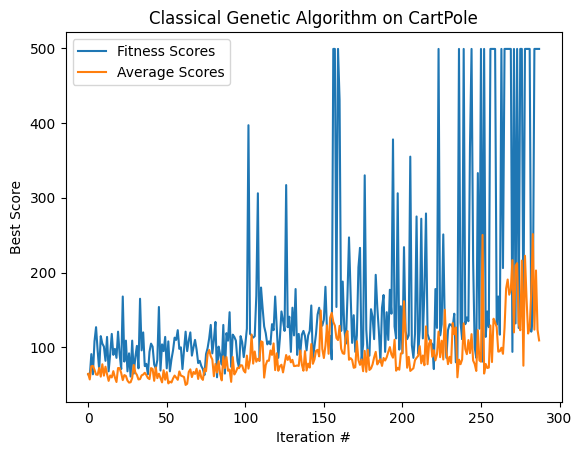

In [17]:
# Test 3: 6*4*2 = 48
n = 6
top = n/3
newpop = 4

fitness3, best3, average3 = GABrandon(select_top_parents, 0.05, 0.1)
print(best3.weights())
print(fitness3)
visualize(best3)

plt.xlabel("Iteration #")
plt.ylabel("Best Score")
plt.title("Classical Genetic Algorithm on CartPole")
plt.plot(fitness3)
plt.plot(average3)
plt.legend(["Fitness Scores", "Average Scores"])